In [581]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings("ignore")
%matplotlib inline

In [582]:
df=pd.read_csv("weatherAUS.csv")

In [583]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,...,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,0.0,No
142189,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,0.0,No
142190,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,0.0,No
142191,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,0.0,No


In [584]:
df["RainTomorrow"].value_counts(normalize=True) #imbalsnced

RainTomorrow
No     0.775819
Yes    0.224181
Name: proportion, dtype: float64

In [585]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [586]:
df.duplicated().sum()

np.int64(0)

In [587]:
df.isna().sum().sort_values(ascending=False)

Sunshine         67816
Evaporation      60843
Cloud3pm         57094
Cloud9am         53657
Pressure9am      14014
Pressure3pm      13981
WindDir9am       10013
WindGustDir       9330
WindGustSpeed     9270
WindDir3pm        3778
Humidity3pm       3610
Temp3pm           2726
WindSpeed3pm      2630
Humidity9am       1774
Rainfall          1406
RainToday         1406
WindSpeed9am      1348
Temp9am            904
MinTemp            637
MaxTemp            322
Location             0
Date                 0
RISK_MM              0
RainTomorrow         0
dtype: int64

In [588]:
df["Date"]=pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df=df.drop(["Date"],axis=1)

In [589]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       142193 non-null  object 
 1   MinTemp        141556 non-null  float64
 2   MaxTemp        141871 non-null  float64
 3   Rainfall       140787 non-null  float64
 4   Evaporation    81350 non-null   float64
 5   Sunshine       74377 non-null   float64
 6   WindGustDir    132863 non-null  object 
 7   WindGustSpeed  132923 non-null  float64
 8   WindDir9am     132180 non-null  object 
 9   WindDir3pm     138415 non-null  object 
 10  WindSpeed9am   140845 non-null  float64
 11  WindSpeed3pm   139563 non-null  float64
 12  Humidity9am    140419 non-null  float64
 13  Humidity3pm    138583 non-null  float64
 14  Pressure9am    128179 non-null  float64
 15  Pressure3pm    128212 non-null  float64
 16  Cloud9am       88536 non-null   float64
 17  Cloud3pm       85099 non-null

In [590]:
df.drop(["RISK_MM"],axis=1,inplace=True)

In [591]:
df.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'Year', 'Month', 'Day'],
      dtype='object')

In [592]:
nummeric=df.select_dtypes(include="number")

<Axes: >

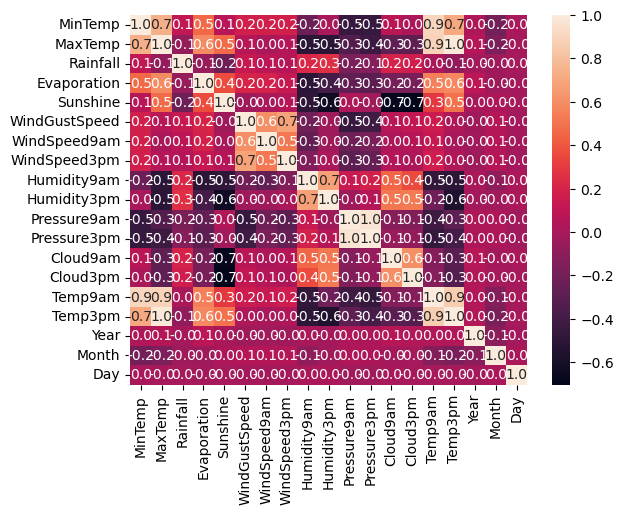

In [593]:
plt.Figure(figsize=(15,10))
sns.heatmap(nummeric.corr(),annot=True,fmt="0.1f")


# spliting

In [594]:
x=df.drop(["RainTomorrow"],axis=1)
y=df["RainTomorrow"]

In [595]:
from sklearn.model_selection import train_test_split,cross_val_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,shuffle=True,stratify=y)


# imputation

In [596]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import (SimpleImputer,IterativeImputer)
iterative_cols = [
    "MinTemp",
    "MaxTemp",
    "Temp9am",
    "Temp3pm",
    "Humidity9am",
    "Humidity3pm",
    "WindGustSpeed",
    "WindSpeed9am",
    "Sunshine",
    "Cloud9am",
    "Cloud3pm"
]
imputer=IterativeImputer(random_state=42)
x_train[iterative_cols]=imputer.fit_transform(x_train[iterative_cols])
x_test[iterative_cols]=imputer.transform(x_test[iterative_cols])


In [597]:
impute=SimpleImputer(strategy="most_frequent")
x_train[["RainToday","WindDir9am","WindGustDir","WindDir3pm"]]=impute.fit_transform(x_train[["RainToday","WindDir9am","WindGustDir","WindDir3pm"]])
x_test[["RainToday","WindDir9am","WindGustDir","WindDir3pm"]]=impute.transform(x_test[["RainToday","WindDir9am","WindGustDir","WindDir3pm"]])

3.7468339786153404


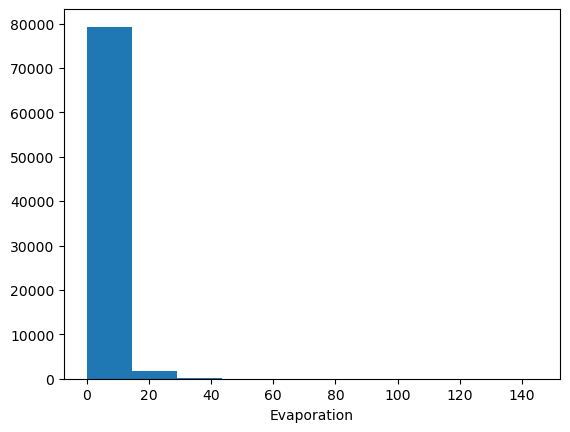

-0.09621089387833553


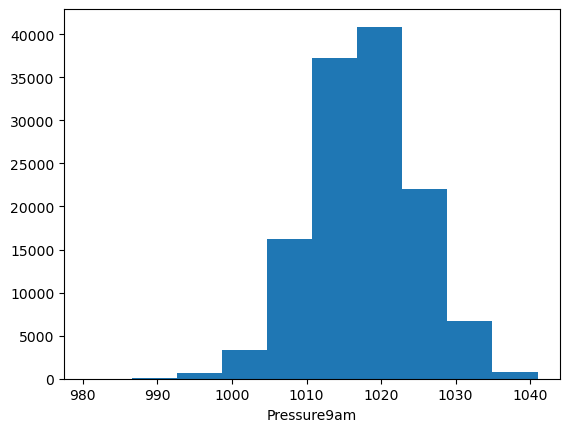

-0.04619761861409882


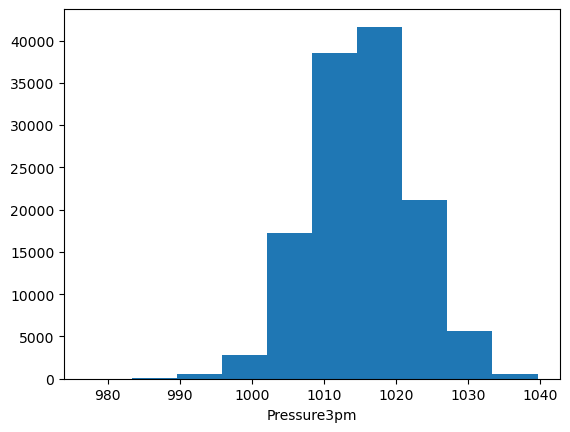

0.6314326033476735


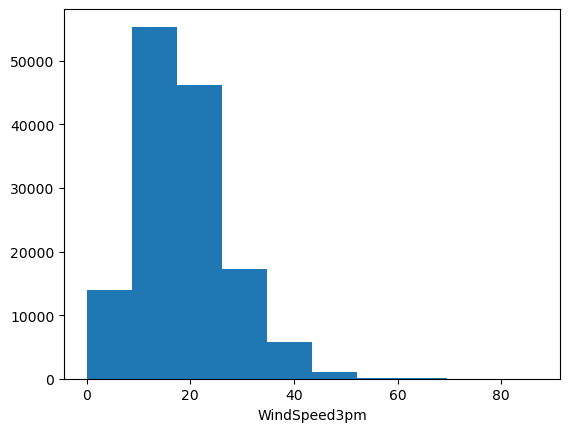

9.888061067872762


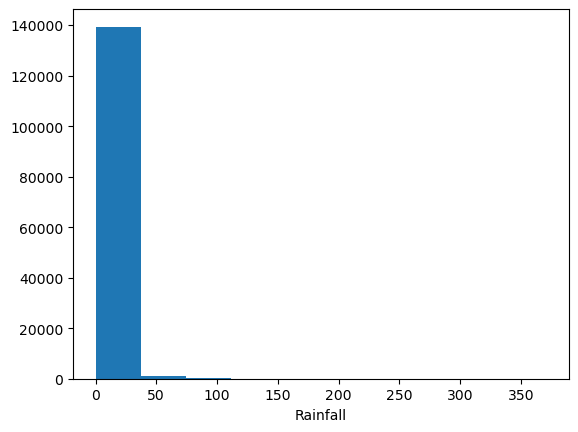

In [598]:
cols=["Evaporation","Pressure9am","Pressure3pm","WindSpeed3pm","Rainfall"]
for col in cols:
    print(df[col].skew())
    plt.xlabel(col)
    plt.hist(df[col])
    plt.show()

In [599]:
imp=SimpleImputer(strategy="median")
x_train[["Rainfall","Evaporation"]]=imp.fit_transform(x_train[["Rainfall","Evaporation"]])
x_test[["Rainfall","Evaporation"]]=imp.transform(x_test[["Rainfall","Evaporation"]])

im=SimpleImputer(strategy="mean")
x_train[["Pressure9am","Pressure3pm","WindSpeed3pm"]]=im.fit_transform(x_train[["Pressure9am","Pressure3pm","WindSpeed3pm"]])
x_test[["Pressure9am","Pressure3pm","WindSpeed3pm"]]=im.transform(x_test[["Pressure9am","Pressure3pm","WindSpeed3pm"]])

In [600]:
df.isna().sum().sum()

np.int64(316559)

In [601]:
cols=["Location",	"WindGustDir",	"WindDir9am","WindDir3pm","RainToday",	"RainTomorrow"]
for col in cols:
    print(f"===={col}====")
    print(df[col].unique())

====Location====
['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond' 'Sydney' 'SydneyAirport'
 'WaggaWagga' 'Williamtown' 'Wollongong' 'Canberra' 'Tuggeranong'
 'MountGinini' 'Ballarat' 'Bendigo' 'Sale' 'MelbourneAirport' 'Melbourne'
 'Mildura' 'Nhil' 'Portland' 'Watsonia' 'Dartmoor' 'Brisbane' 'Cairns'
 'GoldCoast' 'Townsville' 'Adelaide' 'MountGambier' 'Nuriootpa' 'Woomera'
 'Albany' 'Witchcliffe' 'PearceRAAF' 'PerthAirport' 'Perth' 'SalmonGums'
 'Walpole' 'Hobart' 'Launceston' 'AliceSprings' 'Darwin' 'Katherine'
 'Uluru']
====WindGustDir====
['W' 'WNW' 'WSW' 'NE' 'NNW' 'N' 'NNE' 'SW' 'ENE' 'SSE' 'S' 'NW' 'SE' 'ESE'
 nan 'E' 'SSW']
====WindDir9am====
['W' 'NNW' 'SE' 'ENE' 'SW' 'SSE' 'S' 'NE' nan 'SSW' 'N' 'WSW' 'ESE' 'E'
 'NW' 'WNW' 'NNE']
====WindDir3pm====
['WNW' 'WSW' 'E' 'NW' 'W' 'SSE' 'ESE' 'ENE' 'NNW' 'SSW' 'SW' 'SE' 'N' 'S'
 'NNE' nan 'NE']
====RainToday====
['No' 'Yes' nan]
====RainTomorrow====
['No' 'Yes']


# Encoding

In [602]:

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,TargetEncoder
oe=OrdinalEncoder(categories=[["No","Yes"]])
x_train[["RainToday",]]=oe.fit_transform(x_train[["RainToday"]])
x_test[["RainToday"]]=oe.transform(x_test[["RainToday"]])

In [ ]:
df["Location"].value_counts() 

Location
Canberra            3418
Sydney              3337
Perth               3193
Darwin              3192
Hobart              3188
Brisbane            3161
Adelaide            3090
Bendigo             3034
Townsville          3033
AliceSprings        3031
MountGambier        3030
Ballarat            3028
Launceston          3028
Albany              3016
Albury              3011
MelbourneAirport    3009
PerthAirport        3009
Mildura             3007
SydneyAirport       3005
Nuriootpa           3002
Sale                3000
Watsonia            2999
Tuggeranong         2998
Portland            2996
Woomera             2990
Cairns              2988
Cobar               2988
Wollongong          2983
GoldCoast           2980
WaggaWagga          2976
Penrith             2964
NorfolkIsland       2964
Newcastle           2955
SalmonGums          2955
CoffsHarbour        2953
Witchcliffe         2952
Richmond            2951
Dartmoor            2943
NorahHead           2929
BadgerysCreek   

In [608]:
te=TargetEncoder()
x_train["Location"]=te.fit_transform(x_train[["Location"]],y_train)
x_test["Location"]=te.transform(x_test[["Location"]])

In [610]:
from sklearn.preprocessing import OneHotEncoder

ohe_3pm = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

ohe_9am = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

ohe_gust = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)


# WindDir3pm
train_encoded = ohe_3pm.fit_transform(x_train[["WindDir3pm"]])
test_encoded = ohe_3pm.transform(x_test[["WindDir3pm"]])

features_name = ohe_3pm.get_feature_names_out(["WindDir3pm"])

x_train[features_name] = train_encoded
x_test[features_name] = test_encoded

x_train.drop("WindDir3pm", axis=1, inplace=True)
x_test.drop("WindDir3pm", axis=1, inplace=True)


# WindDir9am
train_encoded = ohe_9am.fit_transform(x_train[["WindDir9am"]])
test_encoded = ohe_9am.transform(x_test[["WindDir9am"]])

features_name = ohe_9am.get_feature_names_out(["WindDir9am"])

x_train[features_name] = train_encoded
x_test[features_name] = test_encoded

x_train.drop("WindDir9am", axis=1, inplace=True)
x_test.drop("WindDir9am", axis=1, inplace=True)


# WindGustDir
train_encoded = ohe_gust.fit_transform(x_train[["WindGustDir"]])
test_encoded = ohe_gust.transform(x_test[["WindGustDir"]])

features_name = ohe_gust.get_feature_names_out(["WindGustDir"])

x_train[features_name] = train_encoded
x_test[features_name] = test_encoded

x_train.drop("WindGustDir", axis=1, inplace=True)
x_test.drop("WindGustDir", axis=1, inplace=True)

# scaling

In [612]:
from sklearn.preprocessing import StandardScaler

standard_cols = [
    "Pressure9am",
    "Pressure3pm",
    "Temp9am",
    "Temp3pm"
]

standard_scaler = StandardScaler()

x_train[standard_cols] = standard_scaler.fit_transform(
    x_train[standard_cols]
)

x_test[standard_cols] = standard_scaler.transform(
    x_test[standard_cols]
)

In [614]:
from sklearn.preprocessing import PowerTransformer

power_cols = [
    "WindSpeed3pm",
    "WindSpeed9am",
    "WindGustSpeed"
]

power_transformer = PowerTransformer(
    method="yeo-johnson"
)

x_train[power_cols] = power_transformer.fit_transform(
    x_train[power_cols]
)

x_test[power_cols] = power_transformer.transform(
    x_test[power_cols]
)

# modeling

In [615]:
# from sklearn.linear_model import LogisticRegression,SGDClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.neighbors import KNeighborsClassifier
# # from sklearn.svm import SVC
# from sklearn.tree import DecisionTreeClassifier,plot_tree
# from sklearn.experimental import enable_hist_gradient_boosting #for Histgrad
# from sklearn.ensemble import RandomForestClassifier, BaggingClassifier,ExtraTreesClassifier
# from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier,HistGradientBoostingClassifier
# from sklearn.ensemble import  StackingClassifier
# from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
# from lightgbm import LGBMClassifier

# from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,balanced_accuracy_score#confusion_matrix,classification_report,RocCurveDisplay,roc_auc_score

In [616]:
# models={
#     "lg":LogisticRegression(),
#     "naive":GaussianNB(),
#     "KNN":KNeighborsClassifier(),
#     # "SVM":SVC(),
#     "DTree":DecisionTreeClassifier(),
#     "Random forest":RandomForestClassifier(),
#     "Extra":ExtraTreesClassifier(),
#     "bagging":BaggingClassifier(),
#     "Adaboost":AdaBoostClassifier(),
#     "Gboost":GradientBoostingClassifier(),
#     "HGboost":HistGradientBoostingClassifier(),
#     "stacking":StackingClassifier(
#             estimators=[
#             ('lr',LogisticRegression()),
#             ('rf', RandomForestClassifier(random_state=42))
#         ],
#         final_estimator=LogisticRegression()),
#     "Xgboosing":XGBClassifier(),
#     "Catboosing":CatBoostClassifier(),
#     "LGBM":LGBMClassifier()

# }

# metrics={
#     "acc":accuracy_score,
#     "precision":precision_score,
#     "recall":recall_score,
#     "balance_acc":balanced_accuracy_score,
#     "f1_score":f1_score
    
# }


In [617]:
# results = []

# for model_name, model in models.items():
#     model.fit(x_train, y_train)
#     y_pred_test = model.predict(x_test)

#     row = {"model_name": model_name}

#     for metric_name, metric in metrics.items():
#         row[f"{metric_name}_test"] = metric(y_test, y_pred_test)

#     results.append(row)

# results_df = pd.DataFrame(results)
# results_df

In [618]:
from catboost import CatBoostClassifier

CB = CatBoostClassifier(
    random_seed=42,
    verbose=0
)

CB.fit(x_train, y_train)



In [619]:
import pickle

artifacts = {
    "model": CB,

    "iterative_imputer": imputer,
    "categorical_imputer": impute,
    "median_imputer": imp,
    "mean_imputer": im,

    "rain_encoder": oe,

    "ohe_3pm": ohe_3pm,
    "ohe_9am": ohe_9am,
    "ohe_gust": ohe_gust,

    "location_encoder": te,

    "standard_scaler": standard_scaler,
    "power_transformer": power_transformer,

    "iterative_cols": iterative_cols,
    "standard_cols": standard_cols,
    "power_cols": power_cols,

    "feature_names": x_train.columns.tolist()
}

with open("weather_model.pkl", "wb") as file:
    pickle.dump(artifacts, file)

print("Model saved successfully!")

Model saved successfully!
